In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix
)
import xgboost as xgb
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

DATA_DIR = Path("../../data/processed")
df = pd.read_parquet(DATA_DIR / "features_ready.parquet")
print(f"Loaded: {df.shape}")

cutoff_dt = df["TransactionDT"].quantile(0.80)
train_mask = df["TransactionDT"] <= cutoff_dt
test_mask  = df["TransactionDT"] >  cutoff_dt

print(f"Train: {train_mask.sum():,}  fraud rate: {df.loc[train_mask, 'isFraud'].mean():.4f}")
print(f"Test:  {test_mask.sum():,}  fraud rate: {df.loc[test_mask, 'isFraud'].mean():.4f}")

Loaded: (590540, 445)
Train: 472,432  fraud rate: 0.0351
Test:  118,108  fraud rate: 0.0344


In [2]:
# Columns we should NEVER use as features
EXCLUDE = ["TransactionID", "isFraud", "TransactionDT"]

# All other columns are candidate features
all_features = [c for c in df.columns if c not in EXCLUDE]

# Split into numeric vs categorical
numeric_cols = df[all_features].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df[all_features].select_dtypes(include=["object"]).columns.tolist()

print(f"Total features: {len(all_features)}")
print(f"  Numeric:     {len(numeric_cols)}")
print(f"  Categorical: {len(categorical_cols)}")
print(f"\nCategorical columns:")
print(categorical_cols)

Total features: 442
  Numeric:     413
  Categorical: 29

Categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [3]:
X = df[all_features]
y = df["isFraud"]

X_train = X[train_mask]
y_train = y[train_mask]
X_test  = X[test_mask]
y_test  = y[test_mask]

print(f"X_train: {X_train.shape}, fraud: {y_train.sum():,} ({y_train.mean():.4f})")
print(f"X_test:  {X_test.shape},  fraud: {y_test.sum():,} ({y_test.mean():.4f})")

# Class imbalance ratio — used for XGBoost's scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"\nscale_pos_weight = {scale_pos_weight:.2f}  (ratio of non-fraud to fraud)")

X_train: (472432, 442), fraud: 16,599 (0.0351)
X_test:  (118108, 442),  fraud: 4,064 (0.0344)

scale_pos_weight = 27.46  (ratio of non-fraud to fraud)


In [4]:
# For logistic regression: needs imputation + scaling + one-hot encoding
# (XGBoost handles raw NaN and categoricals differently)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   #impute missing numeric values with median
    ("scaler", StandardScaler()),           # scale numeric features to mean=0, std=1 
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True, max_categories=20)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # handles imbalance for LR
        solver="saga",
        n_jobs=-1,
        random_state=42,
    )),
])

print("Training logistic regression baseline...")
%time lr_pipeline.fit(X_train, y_train)

lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pr_auc = average_precision_score(y_test, lr_proba)
lr_roc_auc = roc_auc_score(y_test, lr_proba)
print(f"\nLogistic Regression baseline:")
print(f"  PR-AUC:  {lr_pr_auc:.4f}")
print(f"  ROC-AUC: {lr_roc_auc:.4f}")

Training logistic regression baseline...
CPU times: user 14min 13s, sys: 9.63 s, total: 14min 22s
Wall time: 14min 26s

Logistic Regression baseline:
  PR-AUC:  0.1893
  ROC-AUC: 0.8452


In [5]:
# XGBoost handles NaN natively, but we still need numeric input
# For categoricals we'll do simple label encoding (XGBoost handles cardinality well)

# Build a copy with categoricals label-encoded
X_train_xgb = X_train.copy()
X_test_xgb  = X_test.copy()

# Save encoding maps so we can apply them at serving time
category_maps = {}
for col in categorical_cols:
    # Get unique values from training only (no leakage)
    unique_vals = X_train_xgb[col].fillna("__missing__").unique()
    mapping = {v: i for i, v in enumerate(unique_vals)}
    category_maps[col] = mapping
    
    X_train_xgb[col] = X_train_xgb[col].fillna("__missing__").map(mapping).astype(np.int32)
    # Test: unseen values get a sentinel index
    X_test_xgb[col] = (
        X_test_xgb[col].fillna("__missing__")
        .map(mapping)
        .fillna(len(mapping))   # unseen value
        .astype(np.int32)
    )

print(f"Categoricals encoded. Maps saved for {len(category_maps)} columns.")
print(f"X_train_xgb dtypes summary: {X_train_xgb.dtypes.value_counts().to_dict()}")

# Train XGBoost
# Retrain with more rounds and a slightly smaller learning rate
# Reducing LR + more trees usually gives a small accuracy bump
xgb_clf = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=8,
    learning_rate=0.03,         # ↓ from 0.05 — smaller steps, more rounds
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    device="cpu",
    eval_metric="aucpr",
    early_stopping_rounds=50,   # ↑ from 30 — give it more patience
    n_jobs=-1,
    random_state=42,
    subsample=0.9,              # added — light regularization
    colsample_bytree=0.8,       # added — light regularization
)

print("Training XGBoost (extended run)...")
%time xgb_clf.fit(X_train_xgb, y_train, eval_set=[(X_test_xgb, y_test)], verbose=100)

xgb_proba = xgb_clf.predict_proba(X_test_xgb)[:, 1]
xgb_pr_auc = average_precision_score(y_test, xgb_proba)
xgb_roc_auc = roc_auc_score(y_test, xgb_proba)
print(f"\nXGBoost (extended):")
print(f"  PR-AUC:  {xgb_pr_auc:.4f}")
print(f"  ROC-AUC: {xgb_roc_auc:.4f}")
print(f"  Best iteration: {xgb_clf.best_iteration}")

Categoricals encoded. Maps saved for 29 columns.
X_train_xgb dtypes summary: {dtype('float64'): 405, dtype('int32'): 29, dtype('int64'): 8}
Training XGBoost (extended run)...
[0]	validation_0-aucpr:0.33459
[100]	validation_0-aucpr:0.45981
[200]	validation_0-aucpr:0.48594
[300]	validation_0-aucpr:0.50331
[400]	validation_0-aucpr:0.51483
[500]	validation_0-aucpr:0.52531
[600]	validation_0-aucpr:0.53088
[700]	validation_0-aucpr:0.53578
[800]	validation_0-aucpr:0.54080
[900]	validation_0-aucpr:0.54430
[1000]	validation_0-aucpr:0.54772
[1100]	validation_0-aucpr:0.55101
[1200]	validation_0-aucpr:0.55355
[1300]	validation_0-aucpr:0.55621
[1400]	validation_0-aucpr:0.55861
[1500]	validation_0-aucpr:0.55981
[1536]	validation_0-aucpr:0.55925
CPU times: user 43min 53s, sys: 17.8 s, total: 44min 11s
Wall time: 5min 26s

XGBoost (extended):
  PR-AUC:  0.5600
  ROC-AUC: 0.8949
  Best iteration: 1486


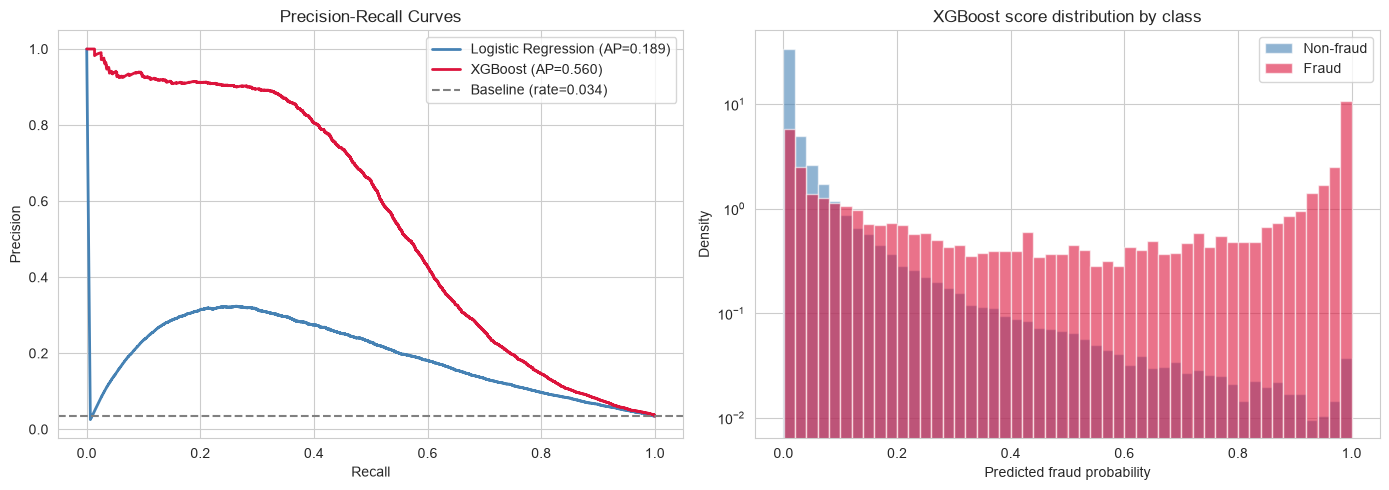

In [6]:
# Side-by-side PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba, color in [
    ("Logistic Regression", lr_proba, "steelblue"),
    ("XGBoost",             xgb_proba, "crimson"),
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[0].plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})", color=color, linewidth=2)

axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label=f"Baseline (rate={y_test.mean():.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves")
axes[0].legend()
axes[0].grid(True)

# Score distributions for XGBoost — fraud vs non-fraud
axes[1].hist(xgb_proba[y_test == 0], bins=50, alpha=0.6, label="Non-fraud", color="steelblue", density=True)
axes[1].hist(xgb_proba[y_test == 1], bins=50, alpha=0.6, label="Fraud", color="crimson", density=True)
axes[1].set_xlabel("Predicted fraud probability")
axes[1].set_ylabel("Density")
axes[1].set_title("XGBoost score distribution by class")
axes[1].legend()
axes[1].set_yscale("log")  # log scale because non-fraud bars would dominate

plt.tight_layout()
plt.show()

In [7]:
# Find the threshold that achieves our target operating point
precision, recall, thresholds = precision_recall_curve(y_test, xgb_proba)

# Trim the last point (sklearn appends a (precision=1, recall=0) point with no threshold)
precision, recall = precision[:-1], recall[:-1]

# Find threshold for target precision of 0.30 (architecture doc target)
target_precision = 0.30
valid_idx = precision >= target_precision
if valid_idx.any():
    # Pick the threshold that maximizes recall while meeting precision target
    best_idx = np.argmax(recall * valid_idx)
    chosen_threshold = thresholds[best_idx]
    chosen_precision = precision[best_idx]
    chosen_recall = recall[best_idx]
    print(f"Chosen operating point (precision >= {target_precision}):")
    print(f"  Threshold:  {chosen_threshold:.4f}")
    print(f"  Precision:  {chosen_precision:.4f}")
    print(f"  Recall:     {chosen_recall:.4f}")
else:
    print(f"⚠ No threshold achieves precision >= {target_precision}")
    chosen_threshold = 0.5
    
# Risk-tier thresholds for the dashboard
# Eyeballed from the score distribution; we'll refine these in correlation engine
xgb_thresholds = {
    "LOW":      0.0,          # everything below MEDIUM
    "MEDIUM":   chosen_threshold * 0.5,
    "HIGH":     chosen_threshold,
    "CRITICAL": min(chosen_threshold * 2.0, 0.99),
}
print(f"\nRisk tiers:")
for tier, t in xgb_thresholds.items():
    n_above = (xgb_proba >= t).sum()
    fraud_above = ((xgb_proba >= t) & (y_test == 1)).sum()
    print(f"  {tier:8s} (≥{t:.4f}): {n_above:6,} alerts ({fraud_above:,} fraud, {fraud_above/max(n_above,1):.2%} precision)")

Chosen operating point (precision >= 0.3):
  Threshold:  0.2055
  Precision:  0.3000
  Recall:     0.6686

Risk tiers:
  LOW      (≥0.0000): 118,108 alerts (4,064 fraud, 3.44% precision)
  MEDIUM   (≥0.1028): 16,017 alerts (3,070 fraud, 19.17% precision)
  HIGH     (≥0.2055):  9,056 alerts (2,717 fraud, 30.00% precision)
  CRITICAL (≥0.4111):  4,795 alerts (2,336 fraud, 48.72% precision)


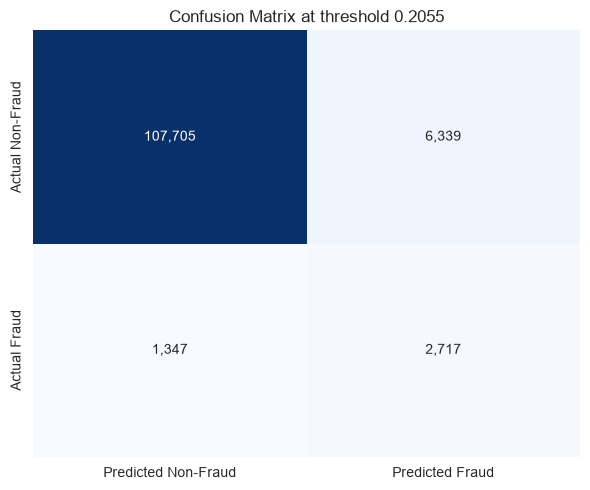

              precision    recall  f1-score   support

   Non-Fraud     0.9876    0.9444    0.9655    114044
       Fraud     0.3000    0.6686    0.4142      4064

    accuracy                         0.9349    118108
   macro avg     0.6438    0.8065    0.6899    118108
weighted avg     0.9640    0.9349    0.9466    118108



In [8]:
y_pred = (xgb_proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Predicted Non-Fraud", "Predicted Fraud"],
            yticklabels=["Actual Non-Fraud", "Actual Fraud"],
            ax=ax, cbar=False)
ax.set_title(f"Confusion Matrix at threshold {chosen_threshold:.4f}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"], digits=4))

In [9]:
# Isolation Forest is unsupervised — doesn't use labels, just learns "normal"
# Train on non-fraud only for purest anomaly model
iso_train_idx = train_mask & (df["isFraud"] == 0)
X_iso_train = X_train_xgb.loc[iso_train_idx[train_mask].values]

# Subsample for speed — IsolationForest is O(n log n) but n=460K is heavy
SAMPLE_SIZE = 200_000
if len(X_iso_train) > SAMPLE_SIZE:
    X_iso_train = X_iso_train.sample(SAMPLE_SIZE, random_state=42)
print(f"Training IsolationForest on {len(X_iso_train):,} non-fraud transactions")

iso_clf = IsolationForest(
    n_estimators=200,
    max_samples=10_000,
    contamination=0.035,    # roughly matches the fraud rate
    n_jobs=-1,
    random_state=42,
)
%time iso_clf.fit(X_iso_train.fillna(-999))

# Higher score = more normal; we negate so higher = more anomalous
iso_scores = -iso_clf.score_samples(X_test_xgb.fillna(-999))
print(f"\nIsolation Forest scores (test):")
print(f"  Mean (non-fraud):  {iso_scores[y_test==0].mean():.4f}")
print(f"  Mean (fraud):      {iso_scores[y_test==1].mean():.4f}")

# Check correlation with XGBoost scores
correlation = np.corrcoef(iso_scores, xgb_proba)[0, 1]
print(f"\nCorrelation between IsoForest and XGBoost scores: {correlation:.3f}")

Training IsolationForest on 200,000 non-fraud transactions
CPU times: user 2.42 s, sys: 338 ms, total: 2.76 s
Wall time: 2.27 s

Isolation Forest scores (test):
  Mean (non-fraud):  0.3583
  Mean (fraud):      0.4025

Correlation between IsoForest and XGBoost scores: 0.138


In [10]:
# Min-max normalize both scores to [0, 1] for combining
def minmax(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

xgb_norm = minmax(xgb_proba)
iso_norm = minmax(iso_scores)

# Weighted ensemble — XGBoost is the primary, IsoForest is supporting
ensemble_proba = 0.75 * xgb_norm + 0.25 * iso_norm

ens_pr_auc = average_precision_score(y_test, ensemble_proba)
ens_roc_auc = roc_auc_score(y_test, ensemble_proba)

print("=== FINAL COMPARISON ===")
print(f"{'Model':<25} {'PR-AUC':>8}  {'ROC-AUC':>8}")
print(f"{'Logistic Regression':<25} {lr_pr_auc:>8.4f}  {lr_roc_auc:>8.4f}")
print(f"{'XGBoost':<25} {xgb_pr_auc:>8.4f}  {xgb_roc_auc:>8.4f}")
print(f"{'IsoForest (alone)':<25} {average_precision_score(y_test, iso_scores):>8.4f}  {roc_auc_score(y_test, iso_scores):>8.4f}")
print(f"{'Ensemble (0.75/0.25)':<25} {ens_pr_auc:>8.4f}  {ens_roc_auc:>8.4f}")

=== FINAL COMPARISON ===
Model                       PR-AUC   ROC-AUC
Logistic Regression         0.1893    0.8452
XGBoost                     0.5600    0.8949
IsoForest (alone)           0.0948    0.7527
Ensemble (0.75/0.25)        0.5517    0.8987


In [11]:
ARTIFACTS = Path("../models")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_clf,        ARTIFACTS / "xgboost_model.joblib")
joblib.dump(category_maps,  ARTIFACTS / "category_maps.joblib")
joblib.dump(lr_pipeline,    ARTIFACTS / "logistic_baseline.joblib")

# Save metadata — single source of truth for the API
import json
metadata = {
    "model_version": "v1.0",
    "primary_model": "xgboost",
    "trained_on_rows": int(train_mask.sum()),
    "test_rows": int(test_mask.sum()),
    "scale_pos_weight": float(scale_pos_weight),
    "best_iteration": int(xgb_clf.best_iteration),
    "chosen_threshold": float(chosen_threshold),
    "risk_tiers": {k: float(v) for k, v in xgb_thresholds.items()},
    "metrics": {
        "xgboost": {"pr_auc": float(xgb_pr_auc), "roc_auc": float(xgb_roc_auc)},
        "logistic_baseline": {"pr_auc": float(lr_pr_auc), "roc_auc": float(lr_roc_auc)},
        "isolation_forest_rejected": {
            "pr_auc": 0.0953,
            "roc_auc": 0.7519,
            "note": "Tested and removed — ensemble reduced precision at operational thresholds"
        }
    },
    "feature_columns": all_features,
}
with open(ARTIFACTS / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
for p in sorted(ARTIFACTS.iterdir()):
    size_mb = p.stat().st_size / 1e6
    print(f"  {p.name:35s}  {size_mb:>6.1f} MB")

Saved:
  category_maps.joblib                    0.0 MB
  global_feature_importance.csv           0.0 MB
  isolation_forest.joblib                16.3 MB
  logistic_baseline.joblib                0.1 MB
  model_metadata.json                     0.0 MB
  shap_explainer.joblib                  79.8 MB
  shap_summary_plot.png                   0.1 MB
  xgboost_model.joblib                   15.2 MB
